In [ ]:
# ============================================================
# FASE 3 - LABEL ENGINEERING
# Cell 1: Setup + Temporal Backward-Labeling + Validasi
# ============================================================

import sys
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------------------------------------
# [1] SYS.PATH SETUP
# Notebook berada di: notebooks/fase_3_label_engineering/
# ML_ROOT = dua level ke atas
# ----------------------------------------------------------
NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# ----------------------------------------------------------
# [2] IMPORT CONFIG - single source of truth
# ----------------------------------------------------------
from config import (
    SENSOR_FILE,
    MAINTENANCE_FILE,
    GLOBAL_SEED,
    W_CRITICAL_HRS,
    W_WARNING_HRS,
    LABEL_MAP,
)

np.random.seed(GLOBAL_SEED)

# ----------------------------------------------------------
# [3] LOAD DATA
# ----------------------------------------------------------
df_sensor = pd.read_csv(
    SENSOR_FILE,
    parse_dates=["timestamp"],
    dtype={"machine_id": str},
)

df_sensor = (
    df_sensor
    .sort_values(["machine_id", "timestamp"], ascending=True)
    .reset_index(drop=True)
)

# ----------------------------------------------------------
# [4] KONFIRMASI SETUP
# ----------------------------------------------------------
SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  SETUP KONFIRMASI")
print(SEP)
print(f"  SRC_PATH         : {SRC_PATH}")
print(f"  GLOBAL_SEED      : {GLOBAL_SEED}")
print(f"  SENSOR_FILE      : {SENSOR_FILE.name}  shape={df_sensor.shape}")
print(f"  W_CRITICAL_HRS   : {W_CRITICAL_HRS} jam")
print(f"  W_WARNING_HRS    : {W_WARNING_HRS} jam")
print(f"  LABEL_MAP        : {LABEL_MAP}")

# ============================================================
# IMPLEMENTASI TEMPORAL BACKWARD-LABELING
# ============================================================

def assign_health_labels(df, w_critical_hrs, w_warning_hrs):
    """
    Temporal backward-labeling per failure event.

    Window CRITICAL : [T_failure - w_critical_hrs, T_failure]
    Window WARNING  : [T_failure - w_warning_hrs,  T_failure - w_critical_hrs)
    WARNING tidak pernah menimpa CRITICAL.
    """
    df = df.copy()
    df["health_label"] = "HEALTHY"

    df_failures = df[df["failure"] == 1]

    for _, row in df_failures.iterrows():
        machine_id       = row["machine_id"]
        T_failure        = row["timestamp"]
        T_critical_start = T_failure - pd.Timedelta(hours=w_critical_hrs)
        T_warning_start  = T_failure - pd.Timedelta(hours=w_warning_hrs)

        # Masker CRITICAL
        mask_critical = (
            (df["machine_id"] == machine_id) &
            (df["timestamp"]  >= T_critical_start) &
            (df["timestamp"]  <= T_failure)
        )
        df.loc[mask_critical, "health_label"] = "CRITICAL"

        # Masker WARNING - JANGAN timpa CRITICAL
        mask_warning = (
            (df["machine_id"]   == machine_id) &
            (df["timestamp"]    >= T_warning_start) &
            (df["timestamp"]    <  T_critical_start) &
            (df["health_label"] != "CRITICAL")
        )
        df.loc[mask_warning, "health_label"] = "WARNING"

    return df


# ----------------------------------------------------------
# EKSEKUSI
# ----------------------------------------------------------
df_labeled = assign_health_labels(df_sensor, W_CRITICAL_HRS, W_WARNING_HRS)

# ============================================================
# LAPORAN VALIDASI
# ============================================================
print(f"\n{SEP}")
print("  LAPORAN VALIDASI LABEL ENGINEERING")
print(SEP)

# --- [A] Distribusi health_label ---
print(f"\n{sep}")
print("  [A] DISTRIBUSI health_label")
print(sep)

label_counts = df_labeled["health_label"].value_counts()
label_pct    = (df_labeled["health_label"].value_counts(normalize=True) * 100).round(4)

dist_df = pd.DataFrame({
    "label" : label_counts.index,
    "count" : label_counts.values,
    "pct_%" : label_pct.values,
})
print()
print(dist_df.to_string(index=False))

# --- [B] Konfirmasi: tidak ada CRITICAL yang tertimpa WARNING ---
print(f"\n{sep}")
print("  [B] KONFIRMASI INTEGRITAS LABEL")
print(sep)

n_failure_rows   = int((df_labeled["failure"] == 1).sum())
n_critical_rows  = int((df_labeled["health_label"] == "CRITICAL").sum())
n_fail_critical  = int(
    ((df_labeled["failure"] == 1) & (df_labeled["health_label"] == "CRITICAL")).sum()
)

flag = "[OK]" if n_failure_rows == n_fail_critical else "[WARN]"

print(f"\n  Total baris failure=1                      : {n_failure_rows}")
print(f"  Baris failure=1 berlabel CRITICAL          : {n_fail_critical}")
print(f"  Total baris berlabel CRITICAL (semua baris): {n_critical_rows}")
print(f"  {flag} Semua failure=1 berlabel CRITICAL   : {n_failure_rows == n_fail_critical}")

# --- [C] Ringkasan per machine_id ---
print(f"\n{sep}")
print("  [C] RINGKASAN PER MESIN")
print(sep)

per_machine = (
    df_labeled
    .groupby("machine_id")["health_label"]
    .value_counts()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
    .reset_index()
)

for lbl in ["HEALTHY", "WARNING", "CRITICAL"]:
    if lbl not in per_machine.columns:
        per_machine[lbl] = 0

per_machine = (
    per_machine[["machine_id", "HEALTHY", "WARNING", "CRITICAL"]]
    .rename(columns={
        "HEALTHY" : "n_HEALTHY",
        "WARNING" : "n_WARNING",
        "CRITICAL": "n_CRITICAL",
    })
    .sort_values("machine_id", ascending=True)
)

print()
print(per_machine.to_string(index=False))

print(f"\n{SEP}")
print("  [OK] Label Engineering selesai. df_labeled siap untuk Fase 4.")
print(SEP)

In [ ]:
# ============================================================
# FASE 3 - SENSOR CONFIRMATION LAYER & EXPORT
# Cell 2: Validasi berbasis sensor + encode label + simpan parquet
# ============================================================

from config import DATA_INTERIM_DIR

SEP = "=" * 65
sep = "-" * 65

# ----------------------------------------------------------
# PARAMETER CONFIRMATION LAYER
# ----------------------------------------------------------
HIGH_PRIORITY_SENSORS    = [
    "temperature",
    "vibration",
    "pressure",
    "rpm",
    "power_consumption",
    "noise_level",
]
MIN_SENSORS_TRIGGERED    = 2
CONFIRMATION_PERCENTILE  = 90

# Hanya gunakan sensor yang benar-benar ada di df_labeled (defensive)
sensors_ok = [s for s in HIGH_PRIORITY_SENSORS if s in df_labeled.columns]

# ============================================================
# LANGKAH 1: Hitung threshold persentil dari baseline HEALTHY
# ============================================================
df_healthy_baseline = df_labeled[df_labeled["health_label"] == "HEALTHY"]

thresholds_p90 = {}
for sensor in sensors_ok:
    thresholds_p90[sensor] = df_healthy_baseline[sensor].quantile(
        CONFIRMATION_PERCENTILE / 100
    )

# ============================================================
# LANGKAH 2: Print tabel threshold
# ============================================================
print(SEP)
print("  SENSOR CONFIRMATION LAYER")
print(SEP)
print(f"  Percentile baseline    : P{CONFIRMATION_PERCENTILE} (dari distribusi HEALTHY)")
print(f"  Min sensors triggered  : {MIN_SENSORS_TRIGGERED}")
print(f"  Sensors digunakan      : {sensors_ok}")

print(f"\n{sep}")
print("  THRESHOLD P90 PER SENSOR (dari baseline HEALTHY)")
print(sep)
print()

thresh_df = pd.DataFrame(
    [{"sensor": k, "threshold_p90": round(v, 4)} for k, v in thresholds_p90.items()]
)
print(thresh_df.to_string(index=False))

# ============================================================
# LANGKAH 3 & 4: Fungsi confirm_label + apply
# ============================================================

def confirm_label(row):
    """
    Konfirmasi label WARNING/CRITICAL menggunakan sensor evidence.

    - HEALTHY    : tidak diubah
    - WARNING/CRITICAL : pertahankan jika >= MIN_SENSORS_TRIGGERED
                         sensor melewati threshold P90-nya,
                         downgrade ke HEALTHY jika kurang.
    """
    if row["health_label"] == "HEALTHY":
        return "HEALTHY"

    count = 0
    for sensor, threshold in thresholds_p90.items():
        if row[sensor] > threshold:
            count += 1

    if count >= MIN_SENSORS_TRIGGERED:
        return row["health_label"]
    else:
        return "HEALTHY"


df_labeled["health_label_confirmed"] = df_labeled.apply(confirm_label, axis=1)

# ============================================================
# LANGKAH 5: Laporan perbandingan sebelum vs sesudah
# ============================================================
print(f"\n{SEP}")
print("  LAPORAN PERBANDINGAN: SEBELUM vs SESUDAH KONFIRMASI")
print(SEP)

# Sebelum
before_counts = df_labeled["health_label"].value_counts()
before_pct    = (df_labeled["health_label"].value_counts(normalize=True) * 100).round(4)

# Sesudah
after_counts  = df_labeled["health_label_confirmed"].value_counts()
after_pct     = (df_labeled["health_label_confirmed"].value_counts(normalize=True) * 100).round(4)

print(f"\n{sep}")
print("  SEBELUM KONFIRMASI (health_label)")
print(sep)
print()
for lbl in ["HEALTHY", "WARNING", "CRITICAL"]:
    cnt = before_counts.get(lbl, 0)
    pct = before_pct.get(lbl, 0.0)
    print(f"    {lbl:<12} : {cnt:>7,}  ({pct:.4f}%)")

print(f"\n{sep}")
print("  SESUDAH KONFIRMASI (health_label_confirmed)")
print(sep)
print()
for lbl in ["HEALTHY", "WARNING", "CRITICAL"]:
    cnt = after_counts.get(lbl, 0)
    pct = after_pct.get(lbl, 0.0)
    print(f"    {lbl:<12} : {cnt:>7,}  ({pct:.4f}%)")

# Downgrade stats
n_downgraded = int(
    ((df_labeled["health_label"] != "HEALTHY") &
     (df_labeled["health_label_confirmed"] == "HEALTHY")).sum()
)
n_nonhealthy = int((df_labeled["health_label"] != "HEALTHY").sum())
pct_downgraded = (n_downgraded / n_nonhealthy * 100) if n_nonhealthy > 0 else 0.0

print(f"\n{sep}")
print("  STATISTIK DOWNGRADE")
print(sep)
print(f"\n  Baris WARNING/CRITICAL sebelum konfirmasi : {n_nonhealthy:,}")
print(f"  Di-downgrade ke HEALTHY                    : {n_downgraded:,}")
print(f"  Persentase downgrade                        : {pct_downgraded:.2f}%")

# ============================================================
# LANGKAH 6: Encoding label
# ============================================================
df_labeled["health_label_encoded"] = (
    df_labeled["health_label_confirmed"].map(LABEL_MAP)
)

print(f"\n{sep}")
print("  ENCODING health_label_confirmed -> health_label_encoded")
print(sep)
print(f"\n  LABEL_MAP : {LABEL_MAP}")
print(f"  NaN setelah encoding : {df_labeled['health_label_encoded'].isna().sum()}")

# ============================================================
# LANGKAH 7: Export ke parquet
# ============================================================
DATA_INTERIM_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PATH = DATA_INTERIM_DIR / "df_sensor_labeled.parquet"

df_labeled.to_parquet(EXPORT_PATH, index=False)

# ============================================================
# LANGKAH 8: Konfirmasi export
# ============================================================
file_size_kb = EXPORT_PATH.stat().st_size / 1024

print(f"\n{SEP}")
print("  EXPORT KONFIRMASI")
print(SEP)
print(f"\n  Path disimpan  : {EXPORT_PATH}")
print(f"  Shape          : {df_labeled.shape}")
print(f"  Ukuran file    : {file_size_kb:.1f} KB")
print(f"  Kolom baru     : health_label | health_label_confirmed | health_label_encoded")
print(f"\n{SEP}")
print("  [OK] Sensor Confirmation Layer & Export selesai.")
print(SEP)

In [5]:
# ============================================================
# FASE 3 - DATA PREVIEW & EXPORT CSV
# Cell 3: Preview per kelas + export CSV untuk inspeksi manual
# ============================================================

import pandas as pd
import sys
from pathlib import Path
from IPython.display import display

# ----------------------------------------------------------
# Pastikan SRC_PATH tersedia (cell dapat dijalankan mandiri)
# ----------------------------------------------------------
NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import DATA_INTERIM_DIR

SEP = "=" * 65
sep = "-" * 65

PARQUET_PATH = DATA_INTERIM_DIR / "df_sensor_labeled.parquet"

PREVIEW_COLS = [
    "timestamp",
    "machine_id",
    "temperature",
    "vibration",
    "noise_level",
    "failure",
    "health_label",
    "health_label_confirmed",
    "health_label_encoded",
]

PREVIEW_LABELS = ["HEALTHY", "WARNING", "CRITICAL"]

# ============================================================
# OPSI A - Preview per Kelas
# ============================================================

# [1] Baca ulang dari parquet
df_check = pd.read_parquet(PARQUET_PATH)

# [2] Info dasar
print(SEP)
print("  DATA PREVIEW - df_sensor_labeled.parquet")
print(SEP)
print(f"\n  Shape  : {df_check.shape}")
print("  Kolom  :")
for col in df_check.columns:
    print(f"    - {col}")

# Hanya gunakan kolom yang tersedia di file (defensive)
cols_ok = [c for c in PREVIEW_COLS if c in df_check.columns]

# [3] Sampel 3 baris per label
for label in PREVIEW_LABELS:
    subset = df_check[df_check["health_label_confirmed"] == label]
    print(f"\n{sep}")
    print(f"  SAMPEL KELAS: {label}  (total: {len(subset):,} baris)")
    print(sep)
    display(subset[cols_ok].head(3))

# ============================================================
# OPSI B - Export CSV Preview
# ============================================================

# [4] Simpan ke CSV
CSV_PATH = DATA_INTERIM_DIR / "df_sensor_labeled_preview.csv"
df_check.to_csv(CSV_PATH, index=False)

# [5] Konfirmasi export
file_size_mb = CSV_PATH.stat().st_size / (1024 * 1024)

print(f"\n{SEP}")
print("  EXPORT CSV KONFIRMASI")
print(SEP)
print(f"\n  Path CSV : {CSV_PATH}")
print(f"  Shape    : {df_check.shape}")
print(f"  Ukuran   : {file_size_mb:.2f} MB")

# [6] Catatan
print(f"\n{sep}")
print("  CATATAN")
print(sep)
print("\n  CATATAN: File CSV ini hanya untuk preview manual.")
print("  Pipeline resmi tetap menggunakan .parquet")
print(f"\n{SEP}")
print("  [OK] Data Preview & Export CSV selesai.")
print(SEP)

  DATA PREVIEW - df_sensor_labeled.parquet

  Shape  : (100000, 14)
  Kolom  :
    - timestamp
    - machine_id
    - temperature
    - vibration
    - pressure
    - rpm
    - power_consumption
    - noise_level
    - humidity
    - operating_hours
    - failure
    - health_label
    - health_label_confirmed
    - health_label_encoded

-----------------------------------------------------------------
  SAMPEL KELAS: HEALTHY  (total: 97,364 baris)
-----------------------------------------------------------------


,timestamp,machine_id,temperature,vibration,noise_level,failure,health_label,health_label_confirmed,health_label_encoded
0,2025-07-01 00:00:00,M-01,72.1,0.52,69.7,0,HEALTHY,HEALTHY,0
1,2025-07-01 01:00:00,M-01,75.0,0.60,72.4,0,HEALTHY,HEALTHY,0
2,2025-07-01 02:00:00,M-01,78.8,0.35,70.1,0,HEALTHY,HEALTHY,0



-----------------------------------------------------------------
  SAMPEL KELAS: WARNING  (total: 1,247 baris)
-----------------------------------------------------------------


,timestamp,machine_id,temperature,vibration,noise_level,failure,health_label,health_label_confirmed,health_label_encoded
2140,2025-09-28 04:00:00,M-01,92.3,0.90,78.4,0,WARNING,WARNING,1
2141,2025-09-28 05:00:00,M-01,87.6,1.22,83.9,0,WARNING,WARNING,1
2142,2025-09-28 06:00:00,M-01,87.7,1.04,81.2,0,WARNING,WARNING,1



-----------------------------------------------------------------
  SAMPEL KELAS: CRITICAL  (total: 1,389 baris)
-----------------------------------------------------------------


,timestamp,machine_id,temperature,vibration,noise_level,failure,health_label,health_label_confirmed,health_label_encoded
2163,2025-09-29 03:00:00,M-01,90.3,1.22,82.6,0,CRITICAL,CRITICAL,2
2164,2025-09-29 04:00:00,M-01,87.0,0.53,82.4,0,CRITICAL,CRITICAL,2
2165,2025-09-29 05:00:00,M-01,81.8,1.77,75.8,0,CRITICAL,CRITICAL,2



  EXPORT CSV KONFIRMASI

  Path CSV : C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monorepo\machine_learning\data\interim\df_sensor_labeled_preview.csv
  Shape    : (100000, 14)
  Ukuran   : 8.43 MB

-----------------------------------------------------------------
  CATATAN
-----------------------------------------------------------------

  CATATAN: File CSV ini hanya untuk preview manual.
  Pipeline resmi tetap menggunakan .parquet

  [OK] Data Preview & Export CSV selesai.


NILAI P90 dan P95

In [1]:
# CELL BARU — Hitung P90/P95 Threshold untuk Frontend Gauge Visualization
import sys, json
import pandas as pd
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))

from src.config import DATA_INTERIM_DIR

HIGH_PRIORITY_SENSORS = [
    "temperature", "vibration", "pressure", "rpm",
    "power_consumption", "noise_level",
]

SEP = "=" * 70
sep = "─" * 70

print(SEP)
print("  GAUGE THRESHOLD CALCULATION — P90 (Warning) & P95 (Critical)")
print(SEP)

# ── 1. Load Data ──────────────────────────────────────────────
df_sensor_labeled = pd.read_parquet(DATA_INTERIM_DIR / "df_sensor_labeled.parquet")
print(f"  Loaded df_sensor_labeled: {df_sensor_labeled.shape}")
print(f"  Health label distribution:\n{df_sensor_labeled['health_label'].value_counts().to_string()}")

# ── 2. Filter HEALTHY saja ───────────────────────────────────
df_healthy = df_sensor_labeled[df_sensor_labeled["health_label"] == "HEALTHY"]
print(f"\n  HEALTHY rows: {len(df_healthy):,} dari {len(df_sensor_labeled):,} total rows")

# ── 3. Hitung threshold ──────────────────────────────────────
print(f"\n{sep}")
print(f"  {'Sensor':<20} {'Min':>8} {'Max':>10} {'P90 (Warn)':>14} {'P95 (Crit)':>14}")
print(sep)

thresholds = {}
for sensor in HIGH_PRIORITY_SENSORS:
    p90     = df_healthy[sensor].quantile(0.90)
    p95     = df_healthy[sensor].quantile(0.95)
    min_val = df_sensor_labeled[sensor].min()
    max_val = df_sensor_labeled[sensor].max()

    thresholds[sensor] = {
        "min":           float(min_val),
        "max":           float(max_val),
        "warning_p90":   float(p90),
        "critical_p95":  float(p95),
        "zone_healthy":  f"< {round(p90, 2)}",
        "zone_warning":  f"{round(p90, 2)} – {round(p95, 2)}",
        "zone_critical": f">= {round(p95, 2)}",
    }

    print(f"  {sensor:<20} {min_val:>8.2f} {max_val:>10.2f} "
          f"{p90:>14.2f} {p95:>14.2f}")

print(sep)

# ── 4. Susun gauge_thresholds JSON ───────────────────────────
gauge_thresholds = {
    "_metadata": {
        "generated_at":   pd.Timestamp.now().isoformat(),
        "source":         "df_sensor_labeled.parquet — HEALTHY rows only",
        "p90_meaning":    "Warning zone threshold (90th percentile of HEALTHY)",
        "p95_meaning":    "Critical zone threshold (95th percentile of HEALTHY)",
        "total_healthy_rows": int(len(df_healthy)),
    },
    "sensors": thresholds,
}

# ── 5. Simpan ke machine_learning/gauge_thresholds.json ──────
OUT_PATH = ML_ROOT / "gauge_thresholds.json"
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(gauge_thresholds, f, indent=2, ensure_ascii=False)

size_kb = OUT_PATH.stat().st_size / 1024
print(f"\n  ✅ Saved: {OUT_PATH}")
print(f"  Size   : {size_kb:.1f} KB")

# ── Preview ───────────────────────────────────────────────────
print(f"\n{SEP}")
print("  PREVIEW gauge_thresholds.json (2 sensor pertama):")
print(SEP)
preview_sensors = list(thresholds.keys())[:2]
preview = {"sensors": {k: thresholds[k] for k in preview_sensors}}
print(json.dumps(preview, indent=2))
print(f"\n  ... dan {len(HIGH_PRIORITY_SENSORS) - 2} sensor lainnya.")
print(SEP)
print("  ✅ SELESAI — gauge_thresholds.json siap dikonsumsi Frontend")
print(SEP)


  GAUGE THRESHOLD CALCULATION — P90 (Warning) & P95 (Critical)
  Loaded df_sensor_labeled: (100000, 14)
  Health label distribution:
health_label
HEALTHY     97315
CRITICAL     1389
WARNING      1296

  HEALTHY rows: 97,315 dari 100,000 total rows

──────────────────────────────────────────────────────────────────────
  Sensor                    Min        Max     P90 (Warn)     P95 (Crit)
──────────────────────────────────────────────────────────────────────
  temperature             58.10     103.30          76.30          77.80
  vibration               -0.09       2.25           0.59           0.64
  pressure                92.10     125.10         103.80         104.80
  rpm                   1964.00    3537.00        2540.00        2589.00
  power_consumption       52.60     126.70          82.10          84.60
  noise_level             57.00     102.90          74.30          75.90
──────────────────────────────────────────────────────────────────────

  ✅ Saved: C:\PORTFOLIO\PR

thresholds validated

  ℹ️  df_sensor_labeled dimuat ulang dari parquet.

  BAGIAN 1 — DISTRIBUSI SENSOR PER KELAS
  HEALTHY  :  97,315 baris
  CRITICAL :   1,389 baris
  TOTAL    : 100,000 baris


  SENSOR: TEMPERATURE
  Kelas          Mean      Std      P10      P25      P50      P90      P95
  ──────────────────────────────────────────────────────────────────────
  HEALTHY       72.35     3.71    68.20    70.00    72.10    76.30    77.80
  WARNING       84.36     5.68    77.15    81.07    84.60    91.30    93.10
  CRITICAL      84.95     5.05    78.40    81.50    84.90    91.40    93.30

  SENSOR: VIBRATION
  Kelas          Mean      Std      P10      P25      P50      P90      P95
  ──────────────────────────────────────────────────────────────────────
  HEALTHY        0.46     0.14     0.32     0.38     0.45     0.59     0.64
  WARNING        0.98     0.31     0.57     0.77     0.98     1.37     1.48
  CRITICAL       0.99     0.30     0.61     0.78     0.99     1.38     1.48

  SENSOR: PRESSURE
  Kelas

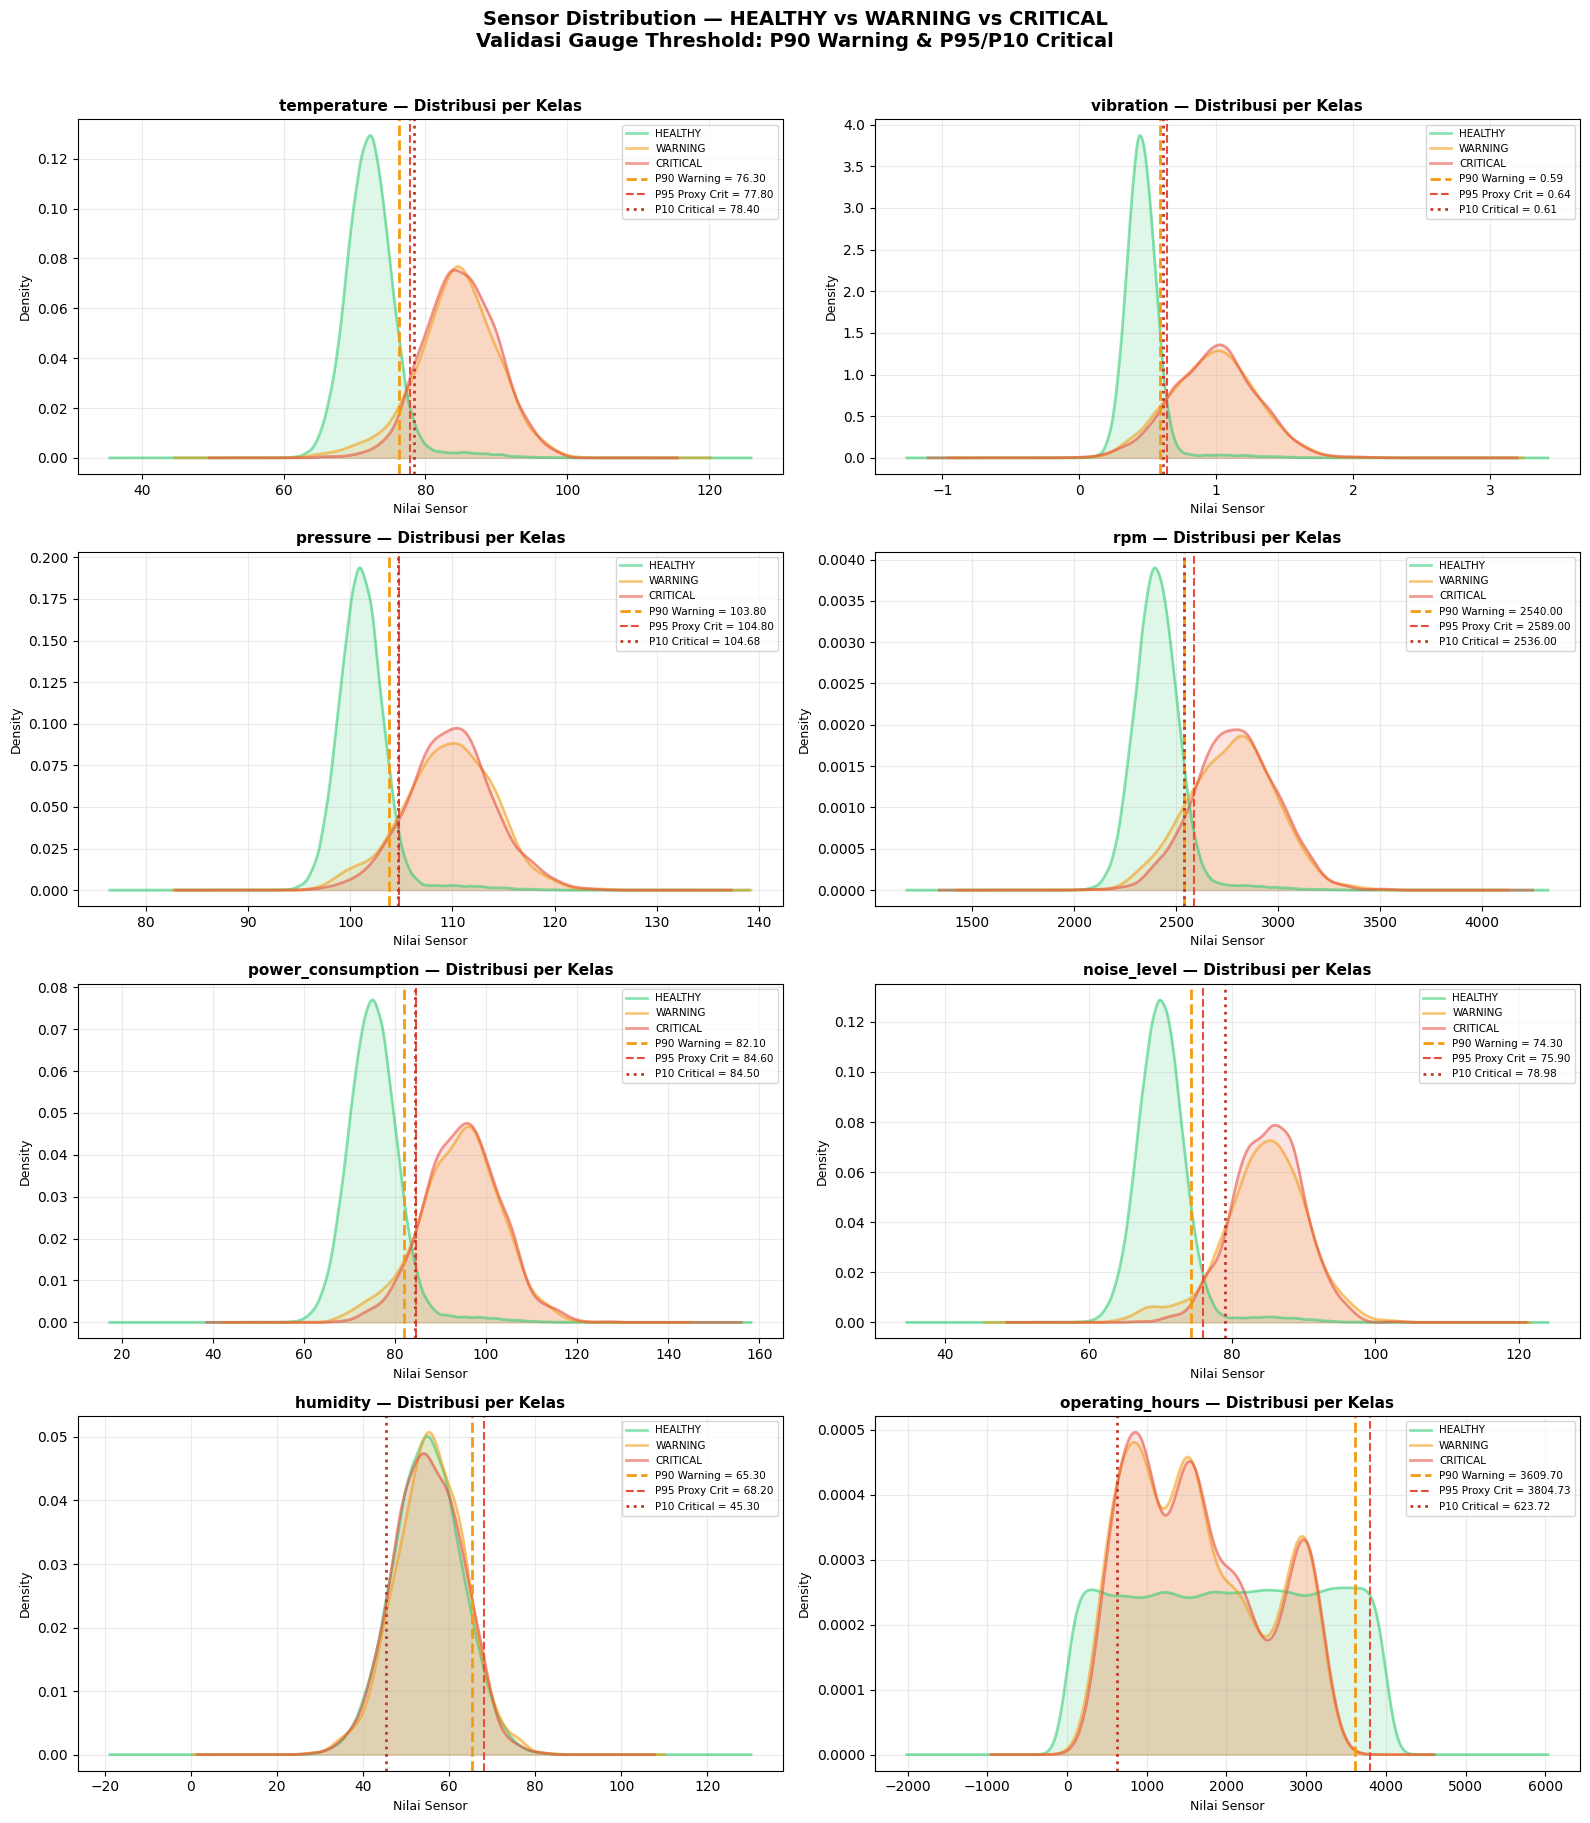

  ✅ Visualisasi KDE ditampilkan.

  BAGIAN 4 — FINAL GAUGE THRESHOLD TABLE
  Sensor                  Warning (P90)  Critical (Validated) Verdict
  ──────────────────────────────────────────────────────────────────────
  temperature                   76.3000               77.8000   ✅ No Overlap
  vibration                      0.5900                0.6250   ⚠️  Overlap
  pressure                     103.8000              104.7400   ⚠️  Overlap
  rpm                         2540.0000             2562.5000   ⚠️  Overlap
  power_consumption             82.1000               84.5500   ⚠️  Overlap
  noise_level                   74.3000               75.9000   ✅ No Overlap
  humidity                      65.3000               56.7500   ⚠️  Overlap
  operating_hours             3609.7000             2214.2250   ⚠️  Overlap
  ──────────────────────────────────────────────────────────────────────

  ✅ Saved: C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monore

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL BARU — Validasi P95 HEALTHY vs P10 CRITICAL
# Gauge Threshold Validation untuk Frontend
# ═══════════════════════════════════════════════════════════════
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))

from src.config import DATA_INTERIM_DIR

HIGH_PRIORITY_SENSORS = [
    "temperature", "vibration", "pressure", "rpm",
    "power_consumption", "noise_level",
    "humidity", "operating_hours",
]

MAIN_SEP  = "=" * 70
sub_sep   = "─" * 70

# ── Load data (mandiri) ────────────────────────────────────────
try:
    _ = df_sensor_labeled  # gunakan variabel dari cell sebelumnya jika ada
    print("  ℹ️  Menggunakan df_sensor_labeled dari session aktif.")
except NameError:
    df_sensor_labeled = pd.read_parquet(DATA_INTERIM_DIR / "df_sensor_labeled.parquet")
    print("  ℹ️  df_sensor_labeled dimuat ulang dari parquet.")

# ══════════════════════════════════════════════════════════════
# BAGIAN 1 — DISTRIBUSI SENSOR PER KELAS
# ══════════════════════════════════════════════════════════════
print(f"\n{MAIN_SEP}")
print("  BAGIAN 1 — DISTRIBUSI SENSOR PER KELAS")
print(MAIN_SEP)

df_healthy  = df_sensor_labeled[df_sensor_labeled["health_label"] == "HEALTHY"]
df_warning  = df_sensor_labeled[df_sensor_labeled["health_label"] == "WARNING"]
df_critical = df_sensor_labeled[df_sensor_labeled["health_label"] == "CRITICAL"]

print(f"  HEALTHY  : {len(df_healthy):>7,} baris")
print(f"  WARNING  : {len(df_warning):>7,} baris")
print(f"  CRITICAL : {len(df_critical):>7,} baris")
print(f"  TOTAL    : {len(df_sensor_labeled):>7,} baris\n")

PERCENTILES = [0.10, 0.25, 0.50, 0.90, 0.95]

for sensor in HIGH_PRIORITY_SENSORS:
    print(f"\n{MAIN_SEP}")
    print(f"  SENSOR: {sensor.upper()}")
    print(MAIN_SEP)
    print(f"  {'Kelas':<10} {'Mean':>8} {'Std':>8} {'P10':>8} {'P25':>8} "
          f"{'P50':>8} {'P90':>8} {'P95':>8}")
    print(f"  {sub_sep}")

    for label, df_cls in [("HEALTHY", df_healthy),
                           ("WARNING", df_warning),
                           ("CRITICAL", df_critical)]:
        vals = df_cls[sensor]
        mean = vals.mean()
        std  = vals.std()
        pcts = {p: vals.quantile(p) for p in PERCENTILES}
        print(f"  {label:<10} {mean:>8.2f} {std:>8.2f} "
              f"{pcts[0.10]:>8.2f} {pcts[0.25]:>8.2f} "
              f"{pcts[0.50]:>8.2f} {pcts[0.90]:>8.2f} "
              f"{pcts[0.95]:>8.2f}")


# ══════════════════════════════════════════════════════════════
# BAGIAN 2 — VALIDASI THRESHOLD
# ══════════════════════════════════════════════════════════════
print(f"\n\n{MAIN_SEP}")
print("  BAGIAN 2 — VALIDASI THRESHOLD")
print(MAIN_SEP)

validated_thresholds = {}

for sensor in HIGH_PRIORITY_SENSORS:
    p90_healthy   = df_healthy[sensor].quantile(0.90)
    p95_healthy   = df_healthy[sensor].quantile(0.95)
    p10_critical  = df_critical[sensor].quantile(0.10)
    p50_critical  = df_critical[sensor].quantile(0.50)
    p10_warning   = df_warning[sensor].quantile(0.10)
    min_val       = df_sensor_labeled[sensor].min()
    max_val       = df_sensor_labeled[sensor].max()
    gap           = p10_critical - p95_healthy

    if p10_critical > p95_healthy:
        recommended = p95_healthy
        verdict     = "✅ P95 VALID — tidak ada overlap"
    else:
        recommended = (p95_healthy + p10_critical) / 2
        verdict     = "⚠️  OVERLAP — gunakan rata-rata"

    validated_thresholds[sensor] = {
        "min":                     float(min_val),
        "max":                     float(max_val),
        "warning_p90":             float(p90_healthy),
        "critical_p95_proxy":      float(p95_healthy),
        "critical_p10_actual":     float(p10_critical),
        "critical_recommended":    float(recommended),
        "validation_verdict":      verdict.replace("✅ ", "").replace("⚠️  ", ""),
        "gap_p95_to_p10critical":  float(gap),
        "zone_healthy":            f"< {round(p90_healthy, 2)}",
        "zone_warning":            f"{round(p90_healthy, 2)} – {round(recommended, 2)}",
        "zone_critical":           f">= {round(recommended, 2)}",
    }

    print(f"\n  [{sensor.upper()}]")
    print(f"    P90 HEALTHY (warning threshold)   : {p90_healthy:>10.4f}")
    print(f"    P95 HEALTHY (proxy critical)       : {p95_healthy:>10.4f}")
    print(f"    P10 CRITICAL (batas bawah kritis)  : {p10_critical:>10.4f}")
    print(f"    P50 CRITICAL (median kritis)       : {p50_critical:>10.4f}")
    print(f"    Gap P95→P10_CRITICAL               : {gap:>+10.4f}  ({'no overlap' if gap > 0 else 'OVERLAP'})")
    print(f"    Verdict                            : {verdict}")
    print(f"    Recommended critical threshold     : {recommended:>10.4f}")


# ══════════════════════════════════════════════════════════════
# BAGIAN 3 — VISUALISASI DISTRIBUSI
# ══════════════════════════════════════════════════════════════
print(f"\n\n{MAIN_SEP}")
print("  BAGIAN 3 — VISUALISASI DISTRIBUSI KDE")
print(MAIN_SEP)

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes_flat = axes.flatten()

color_map = {
    "HEALTHY":  ("#2ecc71", df_healthy),
    "WARNING":  ("#f39c12", df_warning),
    "CRITICAL": ("#e74c3c", df_critical),
}

for idx, sensor in enumerate(HIGH_PRIORITY_SENSORS):
    ax = axes_flat[idx]
    t  = validated_thresholds[sensor]

    # KDE per kelas
    for label, (color, df_cls) in color_map.items():
        df_cls[sensor].plot.kde(ax=ax, color=color, alpha=0.55,
                                linewidth=2, label=label)
        ax.fill_between(
            ax.lines[-1].get_xdata(),
            ax.lines[-1].get_ydata(),
            alpha=0.15, color=color,
        )

    # Vertical lines — thresholds
    p90  = t["warning_p90"]
    p95  = t["critical_p95_proxy"]
    p10c = t["critical_p10_actual"]

    ax.axvline(p90,  color="#f39c12", linestyle="--", linewidth=2.0,
               label=f"P90 Warning = {p90:.2f}")
    ax.axvline(p95,  color="#e74c3c", linestyle="--", linewidth=1.5,
               label=f"P95 Proxy Crit = {p95:.2f}")
    ax.axvline(p10c, color="#c0392b", linestyle=":",  linewidth=2.0,
               label=f"P10 Critical = {p10c:.2f}")

    ax.set_title(f"{sensor} — Distribusi per Kelas", fontsize=11, fontweight="bold")
    ax.set_xlabel("Nilai Sensor", fontsize=9)
    ax.set_ylabel("Density",      fontsize=9)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.grid(alpha=0.25)

plt.suptitle(
    "Sensor Distribution — HEALTHY vs WARNING vs CRITICAL\n"
    "Validasi Gauge Threshold: P90 Warning & P95/P10 Critical",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()
print("  ✅ Visualisasi KDE ditampilkan.")


# ══════════════════════════════════════════════════════════════
# BAGIAN 4 — FINAL GAUGE THRESHOLD TABLE + EXPORT JSON
# ══════════════════════════════════════════════════════════════
print(f"\n{MAIN_SEP}")
print("  BAGIAN 4 — FINAL GAUGE THRESHOLD TABLE")
print(MAIN_SEP)

hdr = f"  {'Sensor':<22} {'Warning (P90)':>14} {'Critical (Validated)':>21} {'Verdict'}"
print(hdr)
print(f"  {sub_sep}")

for sensor in HIGH_PRIORITY_SENSORS:
    t   = validated_thresholds[sensor]
    vrd = "✅ No Overlap" if "VALID" in t["validation_verdict"] else "⚠️  Overlap"
    print(f"  {sensor:<22} {t['warning_p90']:>14.4f} "
          f"{t['critical_recommended']:>21.4f}   {vrd}")

print(f"  {sub_sep}")

# Export JSON
import datetime
gauge_output = {
    "_metadata": {
        "generated_at":        datetime.datetime.now().isoformat(),
        "source":              "df_sensor_labeled.parquet",
        "method":              "P90 HEALTHY=Warning | P95/P10-Critical validated=Critical",
        "total_healthy_rows":  int(len(df_healthy)),
        "total_warning_rows":  int(len(df_warning)),
        "total_critical_rows": int(len(df_critical)),
    },
    "sensors": validated_thresholds,
}

OUT_PATH = ML_ROOT / "gauge_thresholds_validated.json"
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(gauge_output, f, indent=2, ensure_ascii=False)

size_kb = OUT_PATH.stat().st_size / 1024
print(f"\n  ✅ Saved: {OUT_PATH}")
print(f"  Size   : {size_kb:.1f} KB")

print(f"\n{MAIN_SEP}")
print("  PREVIEW — 2 sensor pertama:")
print(MAIN_SEP)
preview = {"sensors": {k: validated_thresholds[k]
                       for k in list(validated_thresholds)[:2]}}
print(json.dumps(preview, indent=2))
print(f"\n{MAIN_SEP}")
print("  ✅ SELESAI — gauge_thresholds_validated.json siap dikonsumsi Frontend")
print(MAIN_SEP)
